# Similarity Theory

**Last Updated: October 22, 2025**

We performed two JAX-ALFA simulations with grids: (i) 64x64x64, and (ii) 128x128x128. The computations use double precision on an NVIDIA A6000-Ada GPU. 

**Load the necessary packages**

In [65]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

**Input & Output Directories**

In [66]:
# User: please change these paths according to your directory structure
BaseDir   = ('/Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/')

# 40x40x40 run
CaseDir1A   = os.path.join(BaseDir, 'examples/NBL_A94/runs/40x40x40/')
OutputDir1A = os.path.join(CaseDir1A, 'output/') # double precision

# 64x64x64 run
CaseDir2A   = os.path.join(BaseDir, 'examples/NBL_A94/runs/64x64x64/')
OutputDir2A = os.path.join(CaseDir2A, 'output/') # double precision 

# 80x80x80 run
CaseDir3A   = os.path.join(BaseDir, 'examples/NBL_A94/runs/80x80x80/')
OutputDir3A = os.path.join(CaseDir3A, 'output/') # double precision 

# 128x128x128 run
CaseDir4A   = os.path.join(BaseDir, 'examples/NBL_A94/runs/128x128x128/')
OutputDir4A = os.path.join(CaseDir4A, 'output/') # double precision 

**Input Information from the Config File**

In [67]:
# Common settings across the simulations
l_x = 4000 # domain length (m)
l_y = 4000 # domain width (m)
l_z = 4000 # domain height (m)
SimTime = 100000  # total simulation time (sec)
OutputInterval = 60 # frequency of output (sec)
z0m = 0.01  # unit: m
f_coriolis = 1e-4  # unit: 1/s
vonk = 0.4  # von Karman constant

# Averaging window
T_start = 70000 # unit: sec
T_end = 100000 # unit: sec

In [68]:
# Simulation 1
nx_1 = 40 # number of grid points in x direction
ny_1 = 40 # number of grid points in y direction
nz_1 = 40 # number of grid points in z direction
dx_1 = l_x / nx_1
dy_1 = l_y / ny_1
dz_1 = l_z / (nz_1 - 1)
x_axis_1 = dx_1 * np.arange(nx_1)

# Simulation 2
nx_2 = 64 # number of grid points in x direction
ny_2 = 64 # number of grid points in y direction
nz_2 = 64 # number of grid points in z direction
dx_2 = l_x / nx_2
dy_2 = l_y / ny_2
dz_2 = l_z / (nz_2 - 1)
x_axis_2 = dx_2 * np.arange(nx_2)

# Simulation 3
nx_3 = 80 # number of grid points in x direction
ny_3 = 80 # number of grid points in y direction
nz_3 = 80 # number of grid points in z direction
dx_3 = l_x / nx_3
dy_3 = l_y / ny_3
dz_3 = l_z / (nz_3 - 1)
x_axis_3 = dx_3 * np.arange(nx_3)

# Simulation 4
nx_4 = 128 # number of grid points in x direction
ny_4 = 128 # number of grid points in y direction
nz_4 = 128 # number of grid points in z direction
dx_4 = l_x / nx_4
dy_4 = l_y / ny_4
dz_4 = l_z / (nz_4 - 1)
x_axis_4 = dx_4 * np.arange(nx_4)

In [69]:
z_scale = l_x/ (2 * np.pi)

**Derived Variables**

In [70]:
# Half levels for u, v, TH variables
z_u_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_u_2 = np.array([(k + 0.5) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_u_3 = np.array([(k + 0.5) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_u_4 = np.array([(k + 0.5) * l_z / (nz_4 - 1) for k in range(nz_4)])

# Full levels for fluxes
z_w_1 = np.array([(k) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_w_2 = np.array([(k) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_w_3 = np.array([(k) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_w_4 = np.array([(k) * l_z / (nz_4 - 1) for k in range(nz_4)])

# Levels for gradients
z_dudz_1 = z_w_1.copy() # same as the flux levels
z_dudz_1[0] = z_u_1[0]  # except the first level 

z_dudz_2 = z_w_2.copy() # same as the flux levels
z_dudz_2[0] = z_u_2[0]  # except the first level

z_dudz_3 = z_w_3.copy() # same as the flux levels
z_dudz_3[0] = z_u_3[0]  # except the first level

z_dudz_4 = z_w_4.copy() # same as the flux levels
z_dudz_4[0] = z_u_4[0]  # except the first level

# Averaging indices
T_start_index = int(T_start / OutputInterval) - 1
T_end_index = int(T_end / OutputInterval) - 1

In [71]:
print(T_start_index, T_end_index)

1165 1665


**Function to Load Statistics & Perform Temporal Averaging**

In [72]:
def LoadStatsAverage(OutputDir, dz, T_start_index, T_end_index):
    
    # Get All Statistics Files in Chronological Order
    OutputFiles = os.path.join(OutputDir, 'ALFA_Statistics_Iteration_*.npz')
    StatFiles   = sorted(
        glob.glob(OutputFiles),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    
    # Initialize lists
    U      = []; V      = []
    dUdz   = []; dVdz   = []
    u2     = []; v2     = []
    w2     = []
    uw     = []; vw     = []
    txz    = []; tyz    = []
    M_sfc  = []; ustar  = []
    Cs2_1  = []; Cs2_2  = []
    Beta1  = []
    
    # Process each file
    for file in StatFiles:
        with np.load(file) as data:
            U.append(data['U']); V.append(data['V'])
            dUdz.append(data['dUdz']); dVdz.append(data['dVdz'])
            u2.append(data['u2']); v2.append(data['v2'])
            w2.append(data['w2'])
            uw.append(data['uw']); vw.append(data['vw'])
            txz.append(data['txz']); tyz.append(data['tyz'])
            M_sfc.append(data['M_sfc']); ustar.append(data['ustar'])
            Cs2_1.append(data['Cs2_1']); Cs2_2.append(data['Cs2_2'])
            Beta1.append(data['Beta1'])
    
    # Convert lists to numpy arrays
    U     = np.array(U);     V     = np.array(V)
    dUdz  = np.array(dUdz);  dVdz  = np.array(dVdz)
    u2    = np.array(u2);    v2    = np.array(v2)
    w2    = np.array(w2)
    uw    = np.array(uw);    vw    = np.array(vw)
    txz   = np.array(txz);   tyz   = np.array(tyz)
    M_sfc = np.array(M_sfc); ustar = np.array(ustar)
    Cs2_1 = np.array(Cs2_1); Cs2_2 = np.array(Cs2_2)
    Beta1 = np.array(Beta1)
    print(Cs2_1.shape, Cs2_2.shape)
    
    # Temporal averaging
    U_avg = np.mean(U[T_start_index:T_end_index+1,:], axis=0)
    V_avg = np.mean(V[T_start_index:T_end_index+1,:], axis=0)

    dUdz_avg = np.mean(dUdz[T_start_index:T_end_index+1,:], axis=0)
    dVdz_avg = np.mean(dVdz[T_start_index:T_end_index+1,:], axis=0)
    
    u2_avg  = np.mean(u2[T_start_index:T_end_index+1,:], axis=0)
    v2_avg  = np.mean(v2[T_start_index:T_end_index+1,:], axis=0)
    w2_avg  = np.mean(w2[T_start_index:T_end_index+1,:], axis=0)
    uw_avg  = np.mean(uw[T_start_index:T_end_index+1,:], axis=0)
    vw_avg  = np.mean(vw[T_start_index:T_end_index+1,:], axis=0)
    txz_avg = np.mean(txz[T_start_index:T_end_index+1,:], axis=0)
    tyz_avg = np.mean(tyz[T_start_index:T_end_index+1,:], axis=0)
    
    M_sfc_avg = np.mean(M_sfc[T_start_index:T_end_index+1])
    # ustar_avg = np.sqrt(np.mean(ustar[T_start_index:T_end_index+1] ** 2)) 
    ustar_avg = np.mean(ustar[T_start_index:T_end_index+1])
    Cs2_1_avg = np.mean(Cs2_1[T_start_index:T_end_index+1], axis=0)
    Cs2_2_avg = np.mean(Cs2_2[T_start_index:T_end_index+1], axis=0)
    Beta1_avg = np.mean(Beta1[T_start_index:T_end_index+1], axis=0)
    
    return (U_avg, V_avg,
            dUdz_avg, dVdz_avg, 
            u2_avg, v2_avg, w2_avg, 
            uw_avg, vw_avg, txz_avg, tyz_avg, 
            M_sfc_avg, ustar_avg, 
            Cs2_1_avg, Cs2_2_avg, Beta1_avg)

**Extract Temporally Averaged Statistics**

In [73]:
(U_avg_1A, V_avg_1A, 
 dUdz_avg_1A, dVdz_avg_1A, 
 u2_avg_1A, v2_avg_1A, w2_avg_1A, 
 uw_avg_1A, vw_avg_1A, txz_avg_1A, tyz_avg_1A, 
 M_sfc_avg_1A, ustar_avg_1A, 
 Cs2_1_avg_1A, Cs2_2_avg_1A, Beta1_avg_1A)\
    = LoadStatsAverage(OutputDir1A, dz_1, T_start_index, T_end_index)

(U_avg_2A, V_avg_2A, 
 dUdz_avg_2A, dVdz_avg_2A, 
 u2_avg_2A, v2_avg_2A, w2_avg_2A, 
 uw_avg_2A, vw_avg_2A, txz_avg_2A, tyz_avg_2A, 
 M_sfc_avg_2A, ustar_avg_2A, 
 Cs2_1_avg_2A, Cs2_2_avg_2A, Beta1_avg_2A)\
    = LoadStatsAverage(OutputDir2A, dz_2, T_start_index, T_end_index)

(U_avg_3A, V_avg_3A, 
 dUdz_avg_3A, dVdz_avg_3A, 
 u2_avg_3A, v2_avg_3A, w2_avg_3A, 
 uw_avg_3A, vw_avg_3A, txz_avg_3A, tyz_avg_3A, 
 M_sfc_avg_3A, ustar_avg_3A, 
 Cs2_1_avg_3A, Cs2_2_avg_3A, Beta1_avg_3A)\
    = LoadStatsAverage(OutputDir3A, dz_3, T_start_index, T_end_index)

(U_avg_4A, V_avg_4A, 
 dUdz_avg_4A, dVdz_avg_4A, 
 u2_avg_4A, v2_avg_4A, w2_avg_4A, 
 uw_avg_4A, vw_avg_4A, txz_avg_4A, tyz_avg_4A, 
 M_sfc_avg_4A, ustar_avg_4A, 
 Cs2_1_avg_4A, Cs2_2_avg_4A, Beta1_avg_4A)\
    = LoadStatsAverage(OutputDir4A, dz_4, T_start_index, T_end_index)


(2000, 40) (2000, 40)
(1666, 64) (1666, 64)
(1666, 80) (1666, 80)
(1666, 128) (1666, 128)


In [74]:
print(ustar_avg_1A, ustar_avg_2A, ustar_avg_3A, ustar_avg_4A)

0.18505854858232007 0.18261531196050412 0.18139521377237786 0.18096903866920197


**Homogeneous vs Heterogeneous**

In [75]:
dMdz_avg_1A = np.sqrt( dUdz_avg_1A ** 2 + dVdz_avg_1A **2)
phiM_1A = (vonk * z_dudz_1) * dMdz_avg_1A / ustar_avg_1A

dMdz_avg_2A = np.sqrt( dUdz_avg_2A ** 2 + dVdz_avg_2A **2)
phiM_2A = (vonk * z_dudz_2) * dMdz_avg_2A / ustar_avg_2A

dMdz_avg_3A = np.sqrt( dUdz_avg_3A ** 2 + dVdz_avg_3A **2)
phiM_3A = (vonk * z_dudz_3) * dMdz_avg_3A / ustar_avg_3A

dMdz_avg_4A = np.sqrt( dUdz_avg_4A ** 2 + dVdz_avg_4A **2)
phiM_4A = (vonk * z_dudz_4) * dMdz_avg_4A / ustar_avg_4A

**Plotting Configurations**

In [76]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

**Profiles of Non-Dimensional Velocity Gradients**

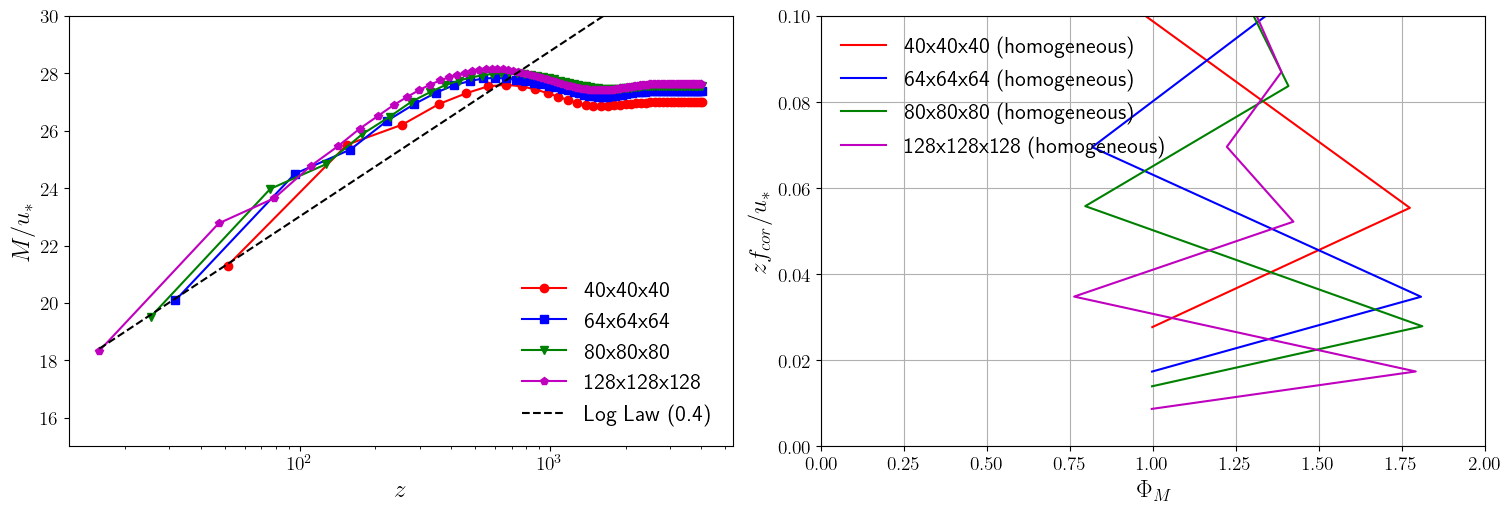

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

MustarRatio_analytical_4 = np.log(z_u_4 / z0m) / 0.4

M_avg_1A = np.sqrt (U_avg_1A ** 2 + V_avg_1A ** 2)
axs[0].plot(z_u_1, M_avg_1A / ustar_avg_1A, 'ro-', label='40x40x40 ')
M_avg_2A = np.sqrt (U_avg_2A ** 2 + V_avg_2A ** 2)
axs[0].plot(z_u_2, M_avg_2A / ustar_avg_2A, 'bs-', label='64x64x64 ')
M_avg_3A = np.sqrt (U_avg_3A ** 2 + V_avg_3A ** 2)
axs[0].plot(z_u_3, M_avg_3A / ustar_avg_3A, 'gv-', label='80x80x80 ')
M_avg_4A = np.sqrt (U_avg_4A ** 2 + V_avg_4A ** 2)
axs[0].plot(z_u_4, M_avg_4A / ustar_avg_4A, 'mp-', label='128x128x128 ')

axs[0].plot(z_u_4, MustarRatio_analytical_4, 'k--', 
            label='Log Law (0.4)')
axs[0].set_xlabel(r"$z$")
axs[0].set_ylabel(r"$M / u_*$")
axs[0].set_xscale('log')
# axs[0].set_xlim((1e-4, 0.5))
axs[0].set_ylim((15, 30))
axs[0].legend(frameon=False, loc='lower right')

axs[1].plot(phiM_1A, z_dudz_1 * f_coriolis / ustar_avg_1A, 'r-', 
            label='40x40x40 (homogeneous)')
axs[1].plot(phiM_2A, z_dudz_2 * f_coriolis / ustar_avg_2A, 'b-', 
            label='64x64x64 (homogeneous)')
axs[1].plot(phiM_3A, z_dudz_3 * f_coriolis / ustar_avg_3A, 'g-', 
            label='80x80x80 (homogeneous)')
axs[1].plot(phiM_4A, z_dudz_4 * f_coriolis / ustar_avg_4A, 'm-', 
            label='128x128x128 (homogeneous)')
axs[1].set_xlabel(r"$\Phi_M$")
axs[1].set_ylabel(r"$z f_{cor} / u_*$")
# axs[1].set_title('Averaging Strategy \#1', fontsize=12)
axs[1].set_xlim((0, 2))
axs[1].set_ylim((0, 0.1))
axs[1].legend(frameon=False, loc='upper left')
axs[1].grid()

plt.show()

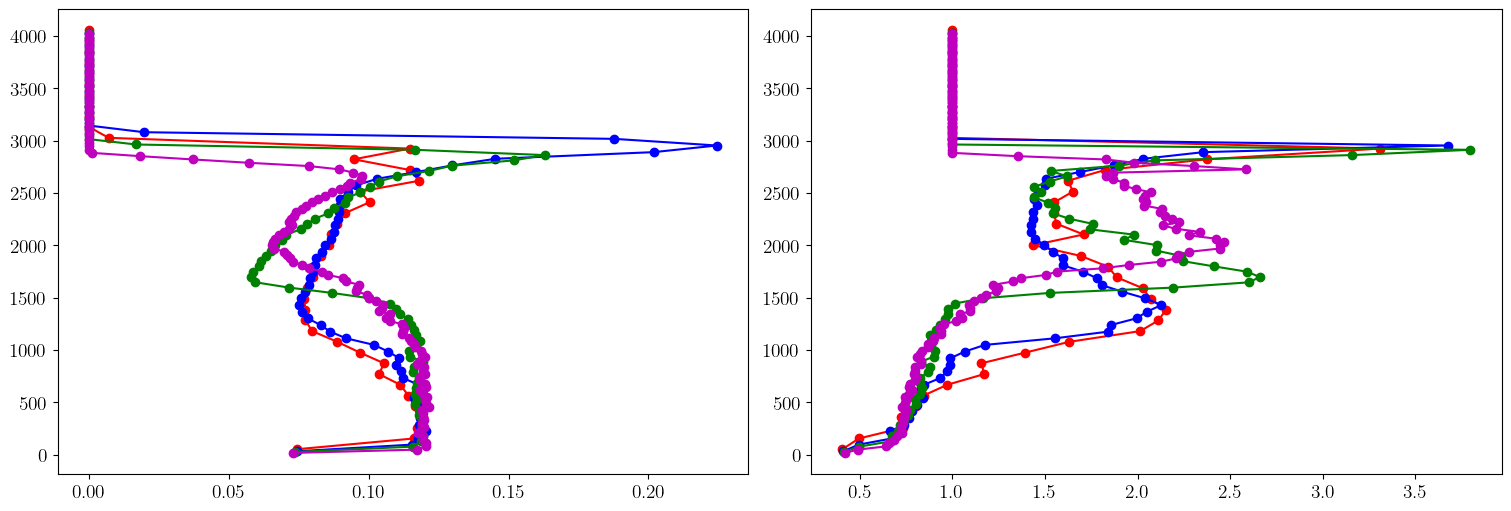

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axs[0].plot(np.sqrt(Cs2_1_avg_1A),z_u_1,'-or')
axs[0].plot(np.sqrt(Cs2_1_avg_2A),z_u_2,'-ob')
axs[0].plot(np.sqrt(Cs2_1_avg_3A),z_u_3,'-og')
axs[0].plot(np.sqrt(Cs2_1_avg_4A),z_u_4,'-om')
axs[1].plot(Beta1_avg_1A,z_u_1,'-or')
axs[1].plot(Beta1_avg_2A,z_u_2,'-ob')
axs[1].plot(Beta1_avg_3A,z_u_3,'-og')
axs[1].plot(Beta1_avg_4A,z_u_4,'-om')
plt.show()

In [79]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
# 
# axs[0].plot(u2_avg_1, z_u_1, 'r-', label='64x64x64')
# axs[0].plot(u2_avg_2, z_u_2, 'b-', label='128x128x128')
# axs[0].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[0].set_xlabel(r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)")
# axs[0].set_ylabel(r"Height (m)")
# axs[0].set_xlim((0, 1.25))
# axs[0].set_ylim((0, 1500))
# axs[0].legend(frameon=False, loc='upper right')
# axs[0].grid()
# 
# axs[1].plot(v2_avg_1, z_u_1, 'r-', label='64x64x64')
# axs[1].plot(v2_avg_2, z_u_2, 'b-', label='128x128x128')
# axs[1].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[1].set_xlabel(r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)")
# axs[1].set_ylabel(r"Height (m)")
# axs[1].set_xlim((0, 1.25))
# axs[1].set_ylim((0, 1500))
# axs[1].legend(frameon=False, loc='upper right')
# axs[1].grid()
# 
# axs[2].plot(w2_avg_1, z_w_1, 'r-', label='64x64x64')
# axs[2].plot(w2_avg_2, z_w_2, 'b-', label='128x128x128')
# axs[2].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[2].set_xlabel(r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)")
# axs[2].set_ylabel(r"Height (m)")
# axs[2].set_xlim((0, 1.25))
# axs[2].set_ylim((0, 1500))
# axs[2].legend(frameon=False, loc='upper right')
# axs[2].grid()
# 
# fig.suptitle("Profiles of Velocity Variances", fontsize=18)
# plt.show()

**Profiles of mean potential temperature, variance, and sensible heat flux**

In [80]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
# 
# axs[0].plot(TH_avg_1, z_u_1, 'r-', label='64x64x64')
# axs[0].plot(TH_avg_2, z_u_2, 'b-', label='128x128x128')
# axs[0].plot(TH_avg_3, z_u_3, 'g-', label='256x256x256')
# axs[0].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[0].set_xlabel(r"Mean Potential Temperature (K)")
# axs[0].set_ylabel(r"Height (m)")
# axs[0].set_xlim((300, 315))
# axs[0].set_ylim((0, 5000))
# axs[0].legend(frameon=False, loc='lower right')
# 
# axs[1].plot(TH2_avg_1, z_u_1, 'r-', label='64x64x64')
# axs[1].plot(TH2_avg_2, z_u_2, 'b-', label='128x128x128')
# axs[1].plot(TH2_avg_3, z_u_3, 'g-', label='256x256x256')
# axs[1].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[1].set_xlabel(r"Resolved $\sigma_\theta^2$ (K$^2$)")
# axs[1].set_ylabel(r"Height (m)")
# axs[1].set_xlim((0, 0.05))
# axs[1].set_ylim((0, 5000))
# axs[1].legend(frameon=False, loc='upper right')
# 
# axs[2].plot(wTH_avg_1 + qz_avg_1, z_w_1, 'r-', label='64x64x64 (Total)')
# axs[2].plot(qz_avg_1, z_w_1, 'r--', label='64x64x64 (SGS)')
# axs[2].plot(wTH_avg_2 + qz_avg_2, z_w_2, 'b-', label='128x128x128 (Total)')
# axs[2].plot(qz_avg_2, z_w_2, 'b--', label='128x128x128 (SGS)')
# axs[2].plot(wTH_avg_3 + qz_avg_3, z_w_3, 'g-', label='256x256x256 (Total)')
# axs[2].plot(qz_avg_3, z_w_3, 'g--', label='256x256x256 (SGS)')
# axs[2].axhline(y=3300, color='k', linestyle=':', linewidth=1.5)  
# axs[2].set_xlabel(r"Sensible Heat Flux (K m/s$^{-1}$)")
# axs[2].set_ylabel(r"Height (m)")
# axs[2].set_xlim((-0.025, 0.07))
# axs[2].set_ylim((0, 5000))
# axs[2].legend(frameon=False, loc='upper right')
# 
# fig.suptitle("Profiles mean potential temperature, variance, and sensible heat flux", fontsize=18)
# plt.show()